# Product Category Classifier — Training & Evaluation

Fine-tunes a ResNet-50 on Open Beauty Facts images to classify products into
**skincare**, **makeup**, or **haircare**.

---
## Setup

In [21]:
import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [22]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models, transforms
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm
import sys, json, random
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
from classifier.dataset import ProductDataset
from classifier.categories import CATEGORY_MAP

## 0. Build Datasets


In [23]:
import subprocess, sys
from pathlib import Path
result = subprocess.run(
    [sys.executable, "-m", "classifier.build_dataset"],
    cwd=Path.cwd().parent,
    capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)


Classified 10,248 products with images
Manifest saved to C:\Projects\cosmetic-expiry-scanner\backend\data\raw\manifest.csv
Downloaded 0/4 new images

Download summary:
  skincare: 6922
  haircare: 2506
  makeup: 820

Total: 10248 images



In [24]:
import subprocess, sys
from pathlib import Path
result = subprocess.run(
    [sys.executable, "-m", "classifier.collect_unlabeled"],
    cwd=Path.cwd().parent,
    capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)


Found 55,016 unlabeled products with images
Manifest saved to C:\Projects\cosmetic-expiry-scanner\backend\data\unlabeled\unlabeled_manifest.csv
Downloaded 0/14 unlabeled images

Total unlabeled images available: 55114



In [25]:
def build_model(num_classes, device):
    m = models.resnet50(weights=None)
    m.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(2048, num_classes)
    )
    m.to(device)
    return m

## Ablation Toggle

Flip `DATASET_VERSION` to **`"v1"`** (hand-labeled only, `raw_v1_clean`), **`"v2"`** (hand +
conservative/strong-keyword auto-labeled, `raw_v2`), or **`"v3"`** (hand + loose/strong+contextual
auto-labeled, `raw_v3_loose`) and re-run the whole train/eval pipeline. All three share the same
10,215 hand-labeled images and exclude the ~5,789 pseudo-labeled strays — v2/v3 differ from v1 (and
each other) only by which auto-labeled batch is added, so the train-dev error delta isolates the
effect of auto-labeling volume/threshold in isolation.

- **v1** = 10,215 manifest hand-labeled images (`data/raw_v1_clean/`)
- **v2** = same 10,215 hand images **plus** the conservative (strong-keyword) auto-labeled batch (`data/raw_v2/`)
- **v3** = same 10,215 hand images **plus** the loose (strong + contextual) auto-labeled batch (`data/raw_v3_loose/`)

In [26]:
DATASET_VERSION = "v1"  # <-- "v1", "v2", or "v3"

# v1: clean hand-labeled only, raw_v1_clean
# v2: hand + conservative (strong-keyword) auto-labeled, raw_v2
# v3: hand + loose (strong + contextual) auto-labeled, raw_v3_loose
# All three differ ONLY by which auto-labeled batch (if any) is added — strays are
# excluded from all — so the train-dev error delta isolates the auto-labeling effect.
assert DATASET_VERSION in ("v1", "v2", "v3"), DATASET_VERSION
_DIR_BY_VERSION = {
    "v1": "raw_v1_clean",
    "v2": "raw_v2",
    "v3": "raw_v3_loose",
}
DATA_DIR = Path.cwd().parent / "data" / _DIR_BY_VERSION[DATASET_VERSION]
print(f"Dataset version: {DATASET_VERSION} -> {DATA_DIR}")

Dataset version: v1 -> c:\Projects\cosmetic-expiry-scanner\backend\data\raw_v1_clean


Train: 6092 | Train-dev: 1073 | Val: 1534 | Test: 1534
Classes: ['haircare', 'makeup', 'skincare']

Train-dev class distribution:
  haircare: 261 (24.3%)
  makeup: 85 (7.9%)
  skincare: 727 (67.8%)
haircare: 1743
makeup: 571
skincare: 4851


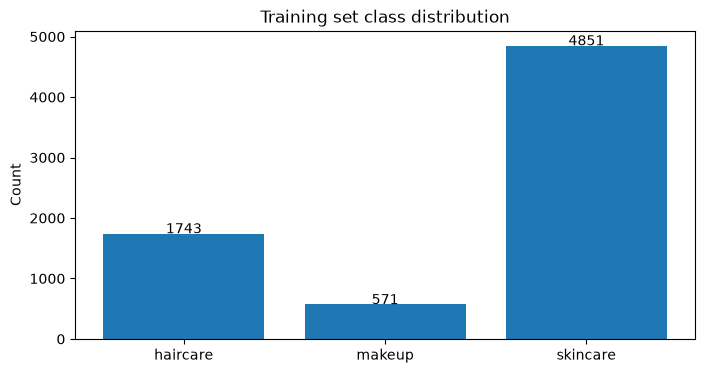

In [27]:
train_ds = ProductDataset(DATA_DIR, split="train")
val_ds   = ProductDataset(DATA_DIR, split="val")
test_ds  = ProductDataset(DATA_DIR, split="test")

# Create train-dev split: hold out 15% of training data, stratified by class
from torch.utils.data import Subset

def stratified_split(dataset, dev_pct=0.15, seed=42):
    """Return (train_indices, dev_indices) with stratified class distribution."""
    class_indices = {}
    for i, (_, label) in enumerate(dataset.samples):
        class_indices.setdefault(label, []).append(i)
    rng = random.Random(seed)
    train_idx, dev_idx = [], []
    for label, indices in class_indices.items():
        rng.shuffle(indices)
        n_dev = max(1, int(len(indices) * dev_pct))
        dev_idx.extend(indices[:n_dev])
        train_idx.extend(indices[n_dev:])
    return train_idx, dev_idx

train_idx, train_dev_idx = stratified_split(train_ds)
train_dev_ds = Subset(train_ds, train_dev_idx)
train_ds_sub = Subset(train_ds, train_idx)

train_loader = DataLoader(train_ds_sub, 32, shuffle=False)
train_dev_loader = DataLoader(train_dev_ds, 32, shuffle=False)
val_loader = DataLoader(val_ds, 32, shuffle=False)
test_loader = DataLoader(test_ds, 32, shuffle=False)

print(f"Train: {len(train_ds_sub)} | Train-dev: {len(train_dev_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
print(f"Classes: {train_ds.classes}")

# Verify train-dev stratification
td_counts = [sum(1 for i in train_dev_idx if train_ds.samples[i][1] == c)
             for c in range(len(train_ds.classes))]
print("\nTrain-dev class distribution:")
for cls, cnt in zip(train_ds.classes, td_counts):
    print(f"  {cls}: {cnt} ({cnt/len(train_dev_ds)*100:.1f}%)")

# Class distribution bar chart
counts = [sum(1 for _, l in train_ds.samples if l == i) for i in range(len(train_ds.classes))]
for cls, cnt in zip(train_ds.classes, counts):
    print(f"{cls}: {cnt}")
plt.figure(figsize=(8, 4))
plt.bar(train_ds.classes, counts)
plt.title("Training set class distribution")
plt.ylabel("Count")
for i, v in enumerate(counts):
    plt.text(i, v + 5, str(v), ha="center")
plt.show()

## 2. Train Model

In [28]:
from classifier.train import train_model

LOAD_FROM_DISK = True

MODEL_DIR = DATA_DIR.parent / "models" / DATASET_VERSION
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / "resnet50_product_category.pt"

CKPT_DIR = MODEL_DIR / "checkpoints"
CKPT_DIR.mkdir(parents=True, exist_ok=True)

if LOAD_FROM_DISK and MODEL_PATH.exists() and (MODEL_DIR / "history.json").exists():
    model = build_model(len(train_ds.classes), DEVICE)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE, weights_only=True))
    with open(MODEL_DIR / "history.json") as f:
        history = json.load(f)
    best_acc = max(history["val_acc"])
    print(f"Loaded model + history from disk (best_acc={best_acc:.2f}%)")
else:
    model, history, best_acc = train_model(
        train_ds_sub, val_ds, DEVICE,
        epochs=20,
        unfreeze_layers=14,
        num_workers=3,
        checkpoint_every=5,
        checkpoint_dir=CKPT_DIR,
        patience=20
    )
    print(f"\nBest validation accuracy: {best_acc:.2f}%")
    torch.save(model.state_dict(), MODEL_PATH)
    with open(MODEL_DIR / "history.json", "w") as f:
        json.dump(history, f)
    print(f"Model + history saved to {MODEL_DIR}")

Loaded model + history from disk (best_acc=72.56%)


## 3. Training Curves

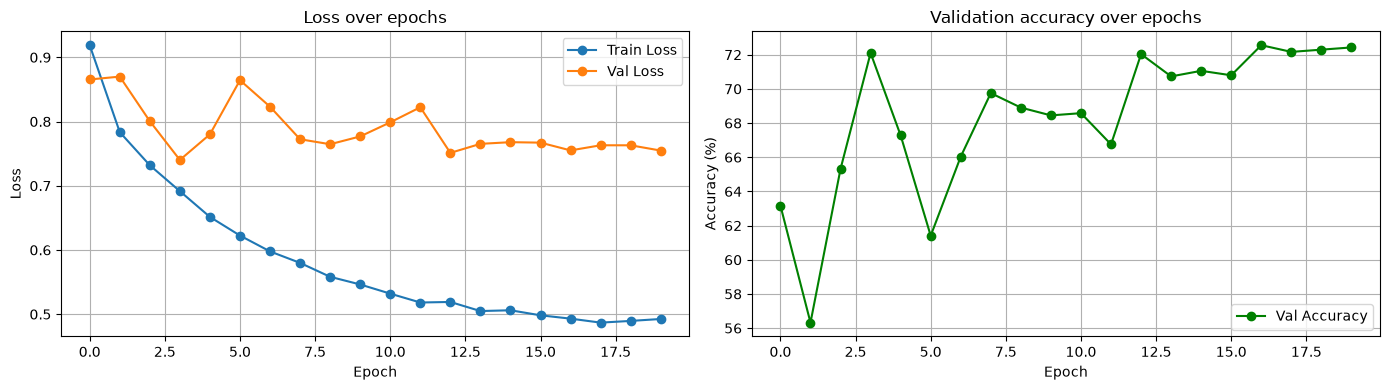

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss
axes[0].plot(history["train_loss"], label="Train Loss", marker="o")
axes[0].plot(history["val_loss"], label="Val Loss", marker="o")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss over epochs")
axes[0].legend()
axes[0].grid(True)

# Accuracy
axes[1].plot(history["val_acc"], label="Val Accuracy", marker="o", color="green")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Validation accuracy over epochs")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 4. Test Set Evaluation

Testing: 100%|██████████| 48/48 [00:04<00:00,  9.96it/s]


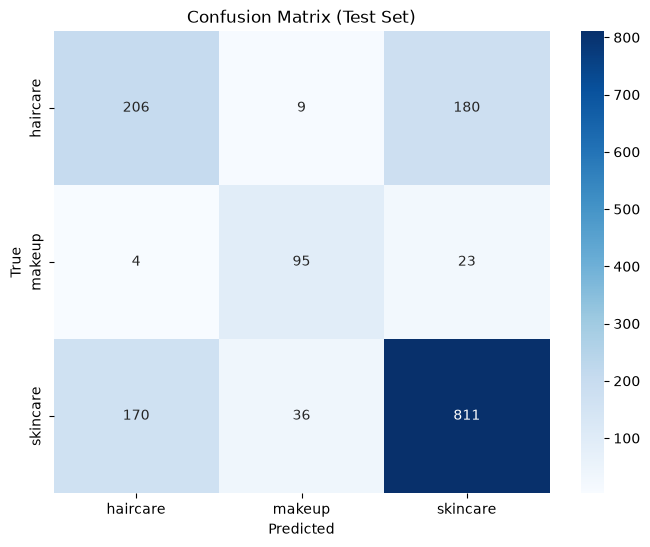

              precision    recall  f1-score   support

    haircare       0.54      0.52      0.53       395
      makeup       0.68      0.78      0.73       122
    skincare       0.80      0.80      0.80      1017

    accuracy                           0.72      1534
   macro avg       0.67      0.70      0.69      1534
weighted avg       0.72      0.72      0.72      1534



In [30]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testing"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_ds.classes,
            yticklabels=train_ds.classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Test Set)")
plt.show()

# Per-class metrics
print(classification_report(all_labels, all_preds,
                            target_names=train_ds.classes))

## 5. Checkpoint Evaluation

Evaluate each saved checkpoint on train-dev and validation sets to find the divergence point.

In [31]:
import glob as glob_mod
import gc

ckpt_paths = sorted(glob_mod.glob(str(CKPT_DIR / "checkpoint_epoch_*.pt")))
if ckpt_paths:
    ckpt_rows = []
    for ckpt_path in ckpt_paths:
        epoch_num = int(Path(ckpt_path).stem.split("_")[-1])
        ckpt_model = build_model(len(train_ds.classes), DEVICE)
        ckpt_model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE, weights_only=True))
        ckpt_model.eval()

        # Train-dev error
        td_correct = td_total = 0
        with torch.no_grad():
            for imgs, lbls in train_dev_loader:
                imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                _, preds = ckpt_model(imgs).max(1)
                td_correct += (preds == lbls).sum().item()
                td_total += lbls.size(0)
        td_err = 100.0 * (1 - td_correct / td_total)

        # Val error from history if available
        if epoch_num <= len(history["val_acc"]):
            val_err = 100.0 - history["val_acc"][epoch_num - 1]
        else:
            v_correct = v_total = 0
            with torch.no_grad():
                for imgs, lbls in val_loader:
                    imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
                    _, preds = ckpt_model(imgs).max(1)
                    v_correct += (preds == lbls).sum().item()
                    v_total += lbls.size(0)
            val_err = 100.0 * (1 - v_correct / v_total)

        # Free memory before next iteration
        del ckpt_model
        gc.collect()
        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

        train_loss = history["train_loss"][epoch_num - 1] if epoch_num <= len(history["train_loss"]) else None
        ckpt_rows.append({
            "epoch": epoch_num,
            "train_loss": round(train_loss, 4) if train_loss else None,
            "val_error_%": round(val_err, 2),
            "train_dev_error_%": round(td_err, 2),
        })

    ckpt_df = pd.DataFrame(ckpt_rows).sort_values("epoch")
    print(ckpt_df.to_string(index=False))
else:
    print("No checkpoints found. Run training with checkpoint_every > 0 to generate them.")

 epoch  train_loss  val_error_%  train_dev_error_%
     5      0.6514        32.72              31.03
    10      0.5463        31.55              32.53
    15      0.5061        28.94              29.73
    20      0.4925        27.57              28.70


## 5b. Train-Dev Error Bucketing

Characterize *why* the model is wrong on train-dev, not just how often.
Collect every misclassified example, sample 40 at random for manual inspection,
and bucket them by likely error cause.

In [32]:
from PIL import Image

model.eval()
misclassifications = []

with torch.no_grad():
    offset = 0
    for images, labels in train_dev_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        probs = torch.softmax(outputs, 1)
        confs, preds = probs.max(1)
        for i in range(labels.size(0)):
            if preds[i] != labels[i]:
                global_idx = train_dev_idx[offset + i]
                file_path = train_ds.samples[global_idx][0]
                misclassifications.append({
                    "path": file_path,
                    "true_label": train_ds.classes[labels[i].item()],
                    "pred_label": train_ds.classes[preds[i].item()],
                    "confidence": confs[i].item(),
                    "bucket": "",
                })
        offset += labels.size(0)

misclass_df = pd.DataFrame(misclassifications)
sample_40 = misclass_df.sample(n=40, random_state=42).reset_index(drop=True)

print(f"Total misclassified: {len(misclassifications)} / {len(train_dev_ds)} "
      f"({100 * len(misclassifications) / len(train_dev_ds):.2f}%)")
sample_40

Total misclassified: 299 / 1073 (27.87%)


,path,true_label,pred_label,confidence,bucket
0,c:\Projects\cosmetic-expiry-scanner\backend\da...,makeup,skincare,0.776988,
1,c:\Projects\cosmetic-expiry-scanner\backend\da...,skincare,haircare,0.373335,
2,c:\Projects\cosmetic-expiry-scanner\backend\da...,skincare,haircare,0.365437,
3,c:\Projects\cosmetic-expiry-scanner\backend\da...,haircare,skincare,0.575324,
4,c:\Projects\cosmetic-expiry-scanner\backend\da...,haircare,skincare,0.726992,
5,c:\Projects\cosmetic-expiry-scanner\backend\da...,makeup,skincare,0.841967,
6,c:\Projects\cosmetic-expiry-scanner\backend\da...,haircare,skincare,0.958846,
7,c:\Projects\cosmetic-expiry-scanner\backend\da...,haircare,skincare,0.558219,
8,c:\Projects\cosmetic-expiry-scanner\backend\da...,haircare,skincare,0.550452,
9,c:\Projects\cosmetic-expiry-scanner\backend\da...,skincare,haircare,0.671252,


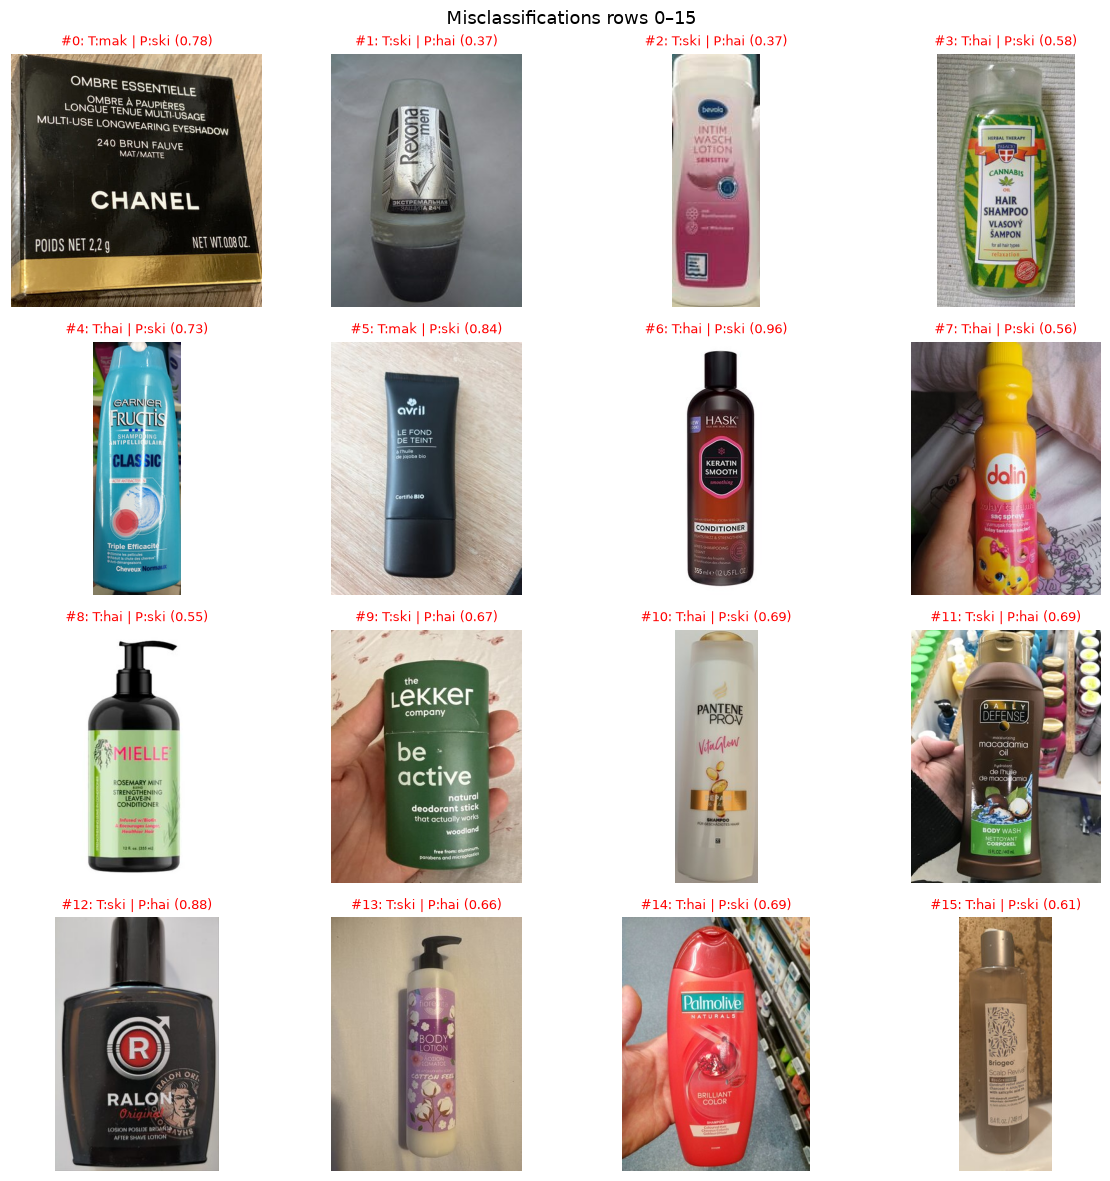

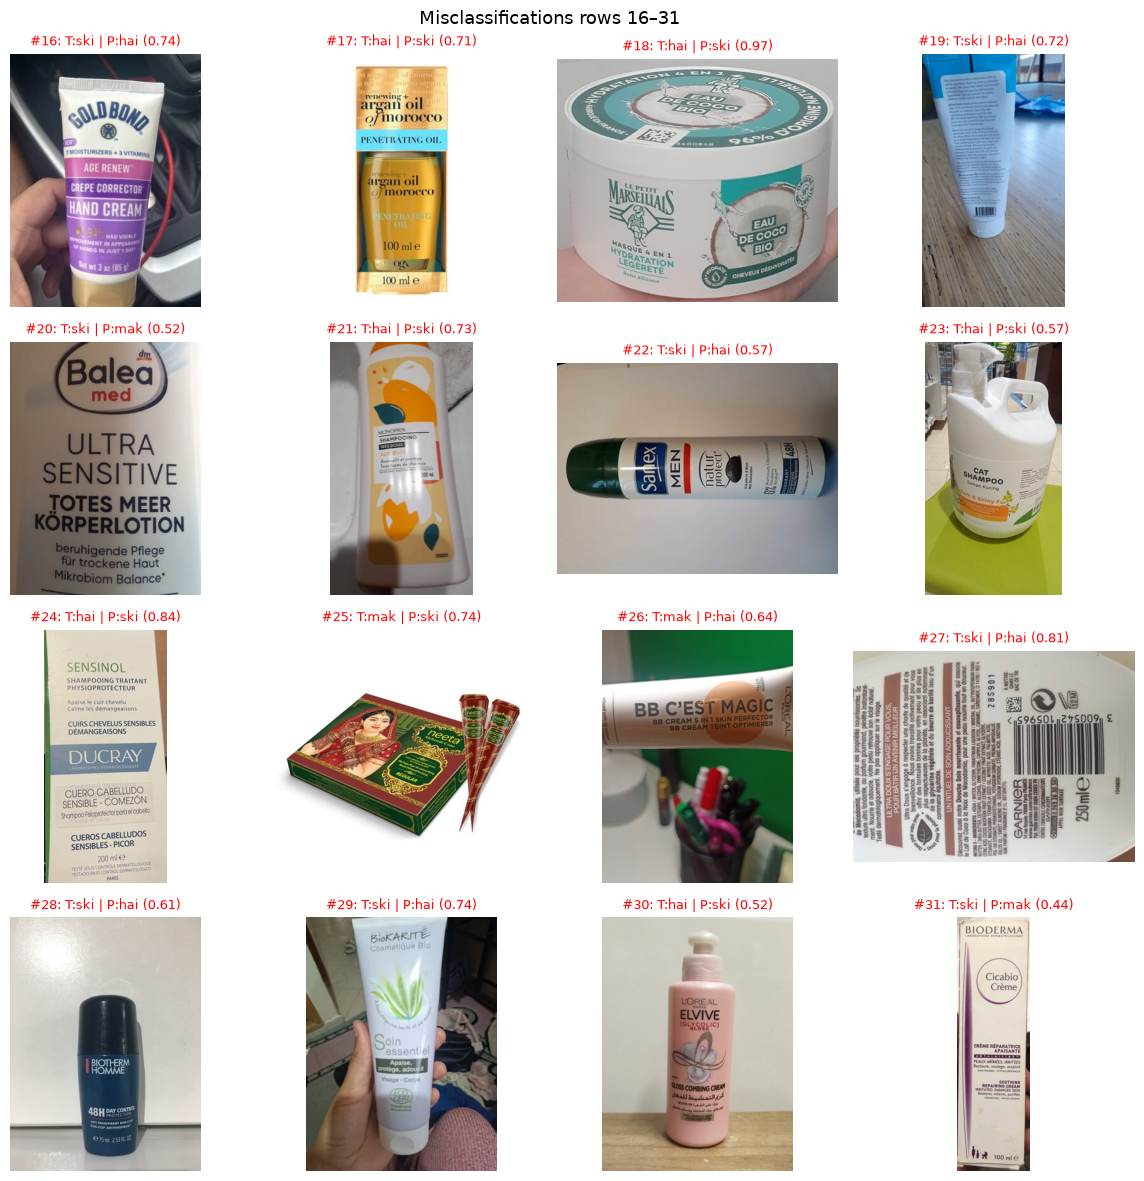

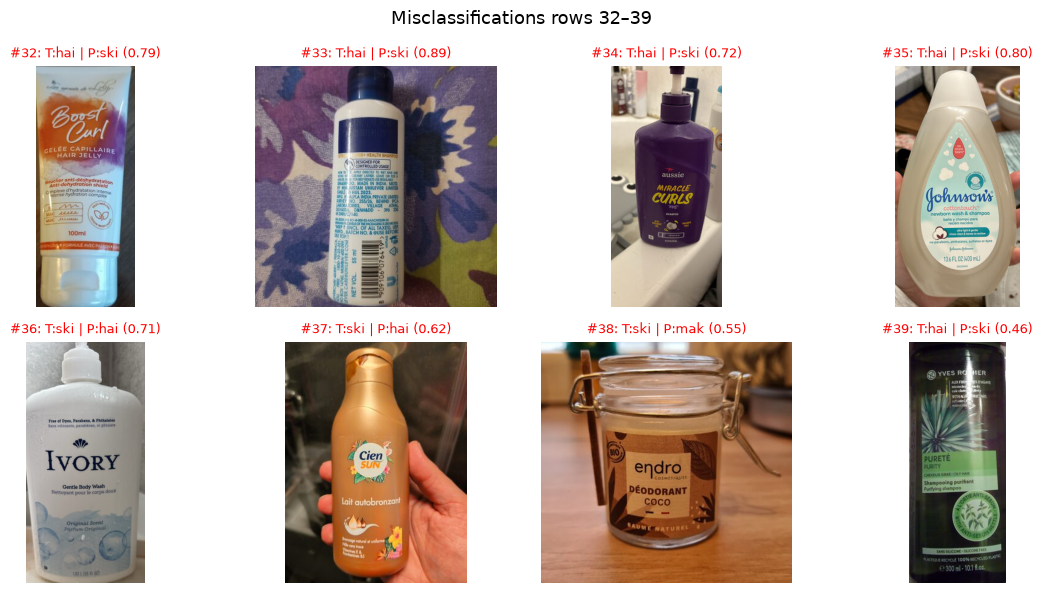

In [33]:
def show_bucket_grid(samples_df, start, end):
    n = end - start
    if n <= 0:
        return
    cols = 4
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))
    axes = axes.flat if n > 1 else [axes]
    for ax in axes:
        ax.axis("off")
    for k, idx in enumerate(range(start, end)):
        row = samples_df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        axes[k].imshow(np.asarray(img))
        axes[k].set_title(
            f"#{idx}: T:{row['true_label'][:3]} | P:{row['pred_label'][:3]} ({row['confidence']:.2f})",
            color="red", fontsize=9,
        )
    plt.suptitle(f"Misclassifications rows {start}–{end - 1}", fontsize=13)
    plt.tight_layout()
    plt.show()

show_bucket_grid(sample_40, 0, 16)
show_bucket_grid(sample_40, 16, 32)
show_bucket_grid(sample_40, 32, 40)

### Bucketing - assign each row one of three buckets

Inspect the 40 rendered images. Each title shows `#<row>` matching the `sample_40` index,
plus true/pred categories and confidence. For each row assign a single character:

- **`1`** = `clear_wrong` - image well-lit, in focus, product label/branding legible; the model got it wrong despite the info being present.
- **`2`** = `hard_photo` - dark, blurry, extreme crop, odd angle; a human would also struggle.
- **`3`** = `ambiguous_product` - clear image but product is natively multi-category/borderline (e.g. face-and-body wash, tinted moisturizer, 2-in-1 shampoo-conditioner).

In the summary cell below, type a 40-character string `codes` where the character at each
position is `1`, `2`, or `3` for that row (grid 1 = rows 0-15, grid 2 = rows 16-31,
grid 3 = rows 32-39). Rows with a `1` are the high-value `clear_wrong` cases worth flagging.

In [34]:
# Enter your 40-digit code here (position = row index, 1=clear_wrong 2=hard_photo 3=ambiguous_product)
codes = "1211311111212231221132121332231222123312"

assert len(codes) == 40, f"Need exactly 40 chars, got {len(codes)}"
BUCKET_MAP = {"1": "clear_wrong", "2": "hard_photo", "3": "ambiguous_product"}
try:
    sample_40["bucket"] = [BUCKET_MAP[c] for c in codes]
except KeyError as e:
    raise ValueError(f"Invalid code char {e}. Use only 1, 2, or 3.") from None

bucket_stats = sample_40.groupby("bucket").agg(
    count=("bucket", "size"),
    mean_conf=("confidence", "mean"),
    median_conf=("confidence", "median"),
).reset_index()
bucket_stats["pct"] = (bucket_stats["count"] / 40 * 100).round(1)

cross_tab = pd.crosstab(sample_40["bucket"], sample_40["true_label"])
cross_tab["dominant_class"] = cross_tab.idxmax(axis=1)

summary = bucket_stats.merge(
    cross_tab[["dominant_class"]], left_on="bucket", right_index=True
)

print("=" * 72)
print("TRAIN-DEV ERROR BUCKETING SUMMARY  (40-sample random subset)")
print("=" * 72)
print(summary.to_string(index=False))
print()

for _, row in summary.iterrows():
    if row["bucket"] == "hard_photo" and row["pct"] > 50:
        print(">> hard_photo >50%: the current ~27% error ceiling is likely close to the")
        print("   practical floor for this dataset's image quality. Focus on data-quality")
        print("   filtering/flagging low-quality training images, or confidence-based UX")
        print("   fallback - not continued model tuning.")
    if row["bucket"] == "clear_wrong" and row["pct"] > 25:
        print(">> clear_wrong >25%: these are the highest-value cases for further model")
        print("   improvement (regularization, capacity, or targeted data) - the needed")
        print("   information is present but the model is missing it. Flag individually.")
    if row["bucket"] == "ambiguous_product" and row["pct"] > 25:
        print(">> ambiguous_product >25%: labeling-scheme issue - consider a 4th 'multi-use'")
        print("   category, or exclude ambiguous products from train-dev/test so error rate")
        print("   reflects only genuinely resolvable cases.")

csv_path = Path.cwd().parent / "data" / "manifests" / "traindev_error_bucketing.csv"
csv_path.parent.mkdir(parents=True, exist_ok=True)
sample_40.to_csv(csv_path, index=False)
print(f"\nSaved annotated table: {csv_path}")

TRAIN-DEV ERROR BUCKETING SUMMARY  (40-sample random subset)
           bucket  count  mean_conf  median_conf  pct dominant_class
ambiguous_product      8   0.673305     0.699342 20.0       skincare
      clear_wrong     17   0.676439     0.671252 42.5       haircare
       hard_photo     15   0.676353     0.709009 37.5       haircare

>> clear_wrong >25%: these are the highest-value cases for further model
   improvement (regularization, capacity, or targeted data) - the needed
   information is present but the model is missing it. Flag individually.

Saved annotated table: c:\Projects\cosmetic-expiry-scanner\backend\data\manifests\traindev_error_bucketing.csv


In [35]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# Clean (val-style) transform: plain 224 resize + normalize. No affine/perspective/
# crop/jitter/flip/rotation - so whether label text survives at 224 is the only question.
CLEAN_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class CleanEvalDataset(Dataset):
    """Same train-dev images as train_dev_ds, but a deterministic no-aug transform."""
    def __init__(self, base_ds, indices, transform):
        self.samples = [base_ds.samples[i] for i in indices]
        self.transform = transform
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), label

train_dev_clean_ds = CleanEvalDataset(train_ds, train_dev_idx, CLEAN_TRANSFORM)
train_dev_clean_loader = DataLoader(train_dev_clean_ds, batch_size=32, shuffle=False)

assert len(train_dev_clean_ds) == len(train_dev_ds)
assert train_dev_clean_ds.samples[0] == train_ds.samples[train_dev_idx[0]]
print(f"Clean train-dev loader: {len(train_dev_clean_ds)} images (no augmentation)")


Clean train-dev loader: 1073 images (no augmentation)


In [36]:
def _eval_error(model, loader, device):
    correct = total = 0
    model.eval()
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            _, preds = model(imgs).max(1)
            correct += (preds == lbls).sum().item()
            total += lbls.size(0)
    return 100.0 * (1 - correct / total)

def _fmt_gap(val, ref):
    diff = val - ref
    sign = "+" if diff >= 0 else ""
    return f"{sign}{diff:.2f}%"

# Reuse Section 8 values if already computed, else recompute locally (self-contained).
try:
    train_err_ref, dev_err_ref = train_err, dev_err
except NameError:
    train_err_ref = _eval_error(model, train_loader, DEVICE)
    dev_err_ref = _eval_error(model, val_loader, DEVICE)

aug_td_err   = _eval_error(model, train_dev_loader, DEVICE)
clean_td_err = _eval_error(model, train_dev_clean_loader, DEVICE)

with open(MODEL_DIR / "hle_results.json") as f:
    hle_err = json.load(f)["human_error_pct"]

print("=" * 72)
print("TRAIN-DEV AUGMENTATION-DEGRADATION TEST")
print("=" * 72)
print(f"  train-dev error (augmented transform, current): {aug_td_err:.2f}%")
print(f"  train-dev error (clean transform, no aug):      {clean_td_err:.2f}%")
print(f"  augmentation-induced delta:                     {aug_td_err - clean_td_err:+.2f} pts\n")

print("-" * 72)
print("DIAGNOSIS WITH CLEAN TRAIN-DEV SUBSTITUTED  (Section 8-style)")
print("-" * 72)
def _diag_row(split, err, gap_to_hle, adj_gap, diagnosis):
    return f"  {split:<11} {err:>7.2f}  {gap_to_hle:>10}  {adj_gap:>20}  {diagnosis}"
print(_diag_row("HLE", hle_err, "--", "--", "Human baseline"))
print(_diag_row("Train", train_err_ref, _fmt_gap(train_err_ref, hle_err),
                f"{_fmt_gap(train_err_ref, hle_err)} (vs HLE)", "Avoidable bias"))
print(_diag_row("Train-dev*", clean_td_err, _fmt_gap(clean_td_err, hle_err),
                f"{_fmt_gap(clean_td_err, train_err_ref)} (vs Train)",
                "Variance" if abs(clean_td_err - train_err_ref) > 1 else "Variance -- negligible"))
print(_diag_row("Dev", dev_err_ref, _fmt_gap(dev_err_ref, hle_err),
                f"{_fmt_gap(dev_err_ref, clean_td_err)} (vs Train-dev*)", "Data mismatch"))
print("  * = clean-transform train-dev (augmentation artifact removed)\n")

delta = aug_td_err - clean_td_err
print(f"**Interpretation:**")
print(f"  Augmentation-induced delta = {delta:+.2f} pts "
      f"({'meets >= 5pt threshold: worth a granular per-image look (Cell 3)' if delta >= 5 else 'small (<5pt): augmentation is NOT the readability driver; the 224 resize + source quality dominate'}).")


TRAIN-DEV AUGMENTATION-DEGRADATION TEST
  train-dev error (augmented transform, current): 28.42%
  train-dev error (clean transform, no aug):      28.33%
  augmentation-induced delta:                     +0.09 pts

------------------------------------------------------------------------
DIAGNOSIS WITH CLEAN TRAIN-DEV SUBSTITUTED  (Section 8-style)
------------------------------------------------------------------------
  HLE            6.40          --                    --  Human baseline
  Train         11.74      +5.34%       +5.34% (vs HLE)  Avoidable bias
  Train-dev*    28.33     +21.93%    +16.60% (vs Train)  Variance
  Dev           27.44     +21.04%  -0.89% (vs Train-dev*)  Data mismatch
  * = clean-transform train-dev (augmentation artifact removed)

**Interpretation:**
  Augmentation-induced delta = +0.09 pts (small (<5pt): augmentation is NOT the readability driver; the 224 resize + source quality dominate).


## 6. Sample Predictions

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9124069..1.9733893].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7925336..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8606442..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0182073..2.4134207].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.622571].
Clip

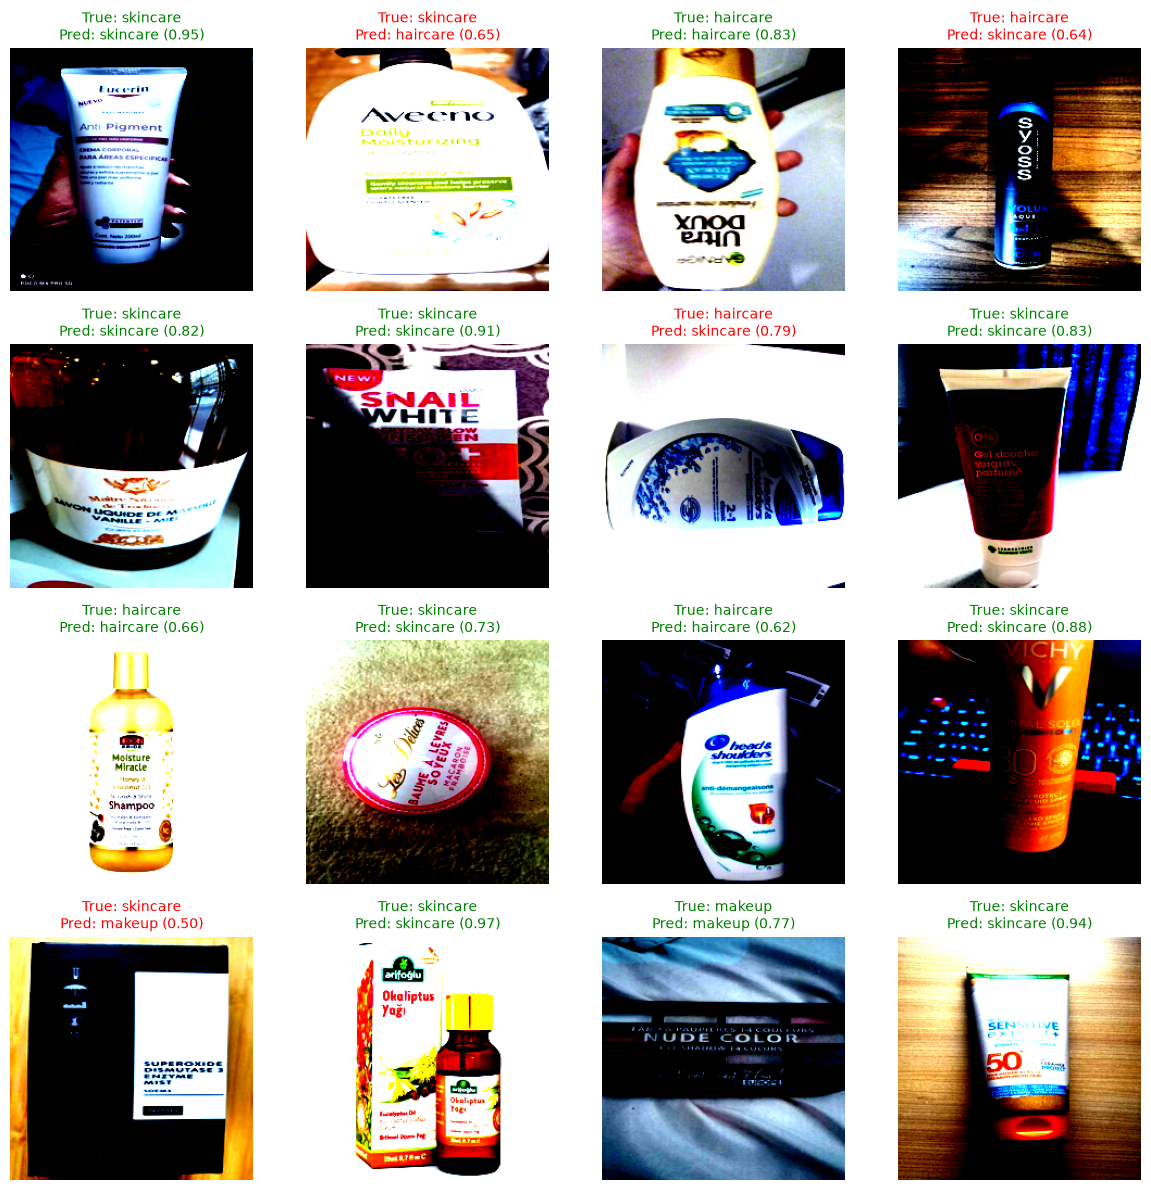

In [37]:
def imshow(img, title=""):
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")

model.eval()
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    img, label = test_ds[int(i)]
    with torch.no_grad():
        output = model(img.unsqueeze(0).to(DEVICE))
        prob = torch.softmax(output, 1)
        conf, pred = prob.max(1)
    true_label = train_ds.classes[label]
    pred_label = train_ds.classes[pred.item()]
    color = "green" if pred_label == true_label else "red"
    ax.imshow(img.cpu().numpy().transpose((1, 2, 0)))
    ax.set_title(f"True: {true_label}\nPred: {pred_label} ({conf.item():.2f})",
                 color=color, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 7. Error Analysis

Human-level error estimated by personally labeling 78 examples using the HLE pipeline.

In [38]:
with open(MODEL_DIR / "hle_results.json") as f:
    hle = json.load(f)

print("=" * 68)
print("HUMAN-LEVEL ERROR ESTIMATION RESULTS")
print("=" * 68)
print(f"  Total examples:        {hle['total_examples']}")
print(f"  Human error (vs GT):   {hle['human_error_pct']}%  ({hle['human_errors']}/{hle['total_examples']})")
print(f"  Model error (vs GT):   {hle['model_error_pct']}%  ({hle['model_errors']}/{hle['total_examples']})")
print(f"  Human-model agreement: {hle['human_model_agreement_pct']}%")
print()
print("-" * 68)
print("PER-CLASS BREAKDOWN")
print("-" * 68)
print(f"  {'Class':<12} {'Count':>5}  {'Human Err':>10}  {'Model Err':>10}")
print(f"  {'-'*12} {'-'*5}  {'-'*10}  {'-'*10}")
for cls, data in hle["per_class"].items():
    print(f"  {cls:<12} {data['count']:>5}  {data['human_error_pct']:>9.1f}%  {data['model_error_pct']:>9.1f}%")
print()
print("=" * 68)

HUMAN-LEVEL ERROR ESTIMATION RESULTS
  Total examples:        78
  Human error (vs GT):   6.4%  (5/78)
  Model error (vs GT):   23.1%  (18/78)
  Human-model agreement: 75.6%

--------------------------------------------------------------------
PER-CLASS BREAKDOWN
--------------------------------------------------------------------
  Class        Count   Human Err   Model Err
  ------------ -----  ----------  ----------
  haircare        18        0.0%       27.8%
  makeup           6        0.0%        0.0%
  skincare        54        9.3%       24.1%



## 8. Error Comparison: All Splits vs Human-Level Error

Programmatic table computed from model predictions on each split.

In [39]:
def eval_error(model, loader, device):
    """Compute error rate (%) for model on loader."""
    correct = total = 0
    model.eval()
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            _, preds = model(imgs).max(1)
            correct += (preds == lbls).sum().item()
            total += lbls.size(0)
    return 100.0 * (1 - correct / total)

train_err = eval_error(model, train_loader, DEVICE)
train_dev_err = eval_error(model, train_dev_loader, DEVICE)
dev_err = eval_error(model, val_loader, DEVICE)
test_err = eval_error(model, test_loader, DEVICE)

with open(MODEL_DIR / "hle_results.json") as f:
    hle = json.load(f)
hle_err = hle["human_error_pct"]

def fmt_gap(val, ref):
    diff = val - ref
    sign = "+" if diff >= 0 else ""
    return f"{sign}{diff:.2f}%"

rows = [
    {"Split": "HLE (Bayes Error)", "Error %": hle_err,
     "Gap to HLE": "--", "Adjacent Gap": "--", "Diagnosis": "Human baseline"},
    {"Split": "Train", "Error %": round(train_err, 2),
     "Gap to HLE": fmt_gap(train_err, hle_err),
     "Adjacent Gap": f"{fmt_gap(train_err, hle_err)} (vs HLE)",
     "Diagnosis": "Avoidable bias"},
    {"Split": "Train-dev", "Error %": round(train_dev_err, 2),
     "Gap to HLE": fmt_gap(train_dev_err, hle_err),
     "Adjacent Gap": f"{fmt_gap(train_dev_err, train_err)} (vs Train)",
     "Diagnosis": "Variance" if abs(train_dev_err - train_err) > 1 else "Variance -- negligible"},
    {"Split": "Dev (Val)", "Error %": round(dev_err, 2),
     "Gap to HLE": fmt_gap(dev_err, hle_err),
     "Adjacent Gap": f"{fmt_gap(dev_err, train_dev_err)} (vs Train-dev)",
     "Diagnosis": "Data mismatch"},
    {"Split": "Test", "Error %": round(test_err, 2),
     "Gap to HLE": fmt_gap(test_err, hle_err),
     "Adjacent Gap": f"{fmt_gap(test_err, dev_err)} (vs Dev)",
     "Diagnosis": "Consistent with dev"},
]

error_df = pd.DataFrame(rows)
print(error_df.to_string(index=False))

print("\n**Key Insights:**")
print(f"1. Bayes/Train gap ({fmt_gap(train_err, hle_err)}) is the avoidable bias.")
td_gap = train_dev_err - train_err
print(f"2. Train/Train-dev gap ({td_gap:+.2f}%) is {'negligible -- rules out variance' if abs(td_gap) < 1 else 'significant'}.")
mismatch_gap = dev_err - train_dev_err
print(f"3. Train-dev/Dev gap ({mismatch_gap:+.2f}%) is {'the largest -- data mismatch' if mismatch_gap > 5 else 'moderate'}.")
dev_test_gap = test_err - dev_err
print(f"4. Dev/Test gap ({dev_test_gap:+.2f}%) is {'negligible -- dev and test consistent' if abs(dev_test_gap) < 2 else 'notable'}.")

            Split  Error % Gap to HLE          Adjacent Gap           Diagnosis
HLE (Bayes Error)     6.40         --                    --      Human baseline
            Train    12.15     +5.75%       +5.75% (vs HLE)      Avoidable bias
        Train-dev    28.05    +21.65%    +15.91% (vs Train)            Variance
        Dev (Val)    27.44    +21.04% -0.61% (vs Train-dev)       Data mismatch
             Test    27.51    +21.11%       +0.07% (vs Dev) Consistent with dev

**Key Insights:**
1. Bayes/Train gap (+5.75%) is the avoidable bias.
2. Train/Train-dev gap (+15.91%) is significant.
3. Train-dev/Dev gap (-0.61%) is moderate.
4. Dev/Test gap (+0.07%) is negligible -- dev and test consistent.


## 9. Extended Training -- Bias Investigation

Train for more epochs (40) with checkpoints every 5 epochs to find where
train-dev error starts climbing (divergence point = overfitting indicator).

In [ ]:
EXTENDED_EPOCHS = 40
EXTENDED_CKPT_DIR = MODEL_DIR / "extended_checkpoints"
EXTENDED_CKPT_DIR.mkdir(parents=True, exist_ok=True)
EXTENDED_HISTORY_PATH = MODEL_DIR / "extended_history.json"

if LOAD_FROM_DISK and EXTENDED_HISTORY_PATH.exists() and any(EXTENDED_CKPT_DIR.glob("checkpoint_epoch_*.pt")):
    with open(EXTENDED_HISTORY_PATH) as f:
        ext_history = json.load(f)
    print(f"Loaded extended training history ({len(ext_history['val_acc'])} epochs) from disk")
else:
    ext_model, ext_history, ext_best_acc = train_model(
        train_ds_sub, val_ds, DEVICE,
        epochs=EXTENDED_EPOCHS,
        unfreeze_layers=14,
        num_workers=0,
        checkpoint_every=5,
        checkpoint_dir=EXTENDED_CKPT_DIR,
        patience=40,
    )
    torch.save(ext_model.state_dict(), MODEL_DIR / "resnet50_extended.pt")
    with open(EXTENDED_HISTORY_PATH, "w") as f:
        json.dump(ext_history, f)
    print(f"Extended training complete. Best val accuracy: {ext_best_acc:.2f}%")

## 10. Extended Checkpoint Evaluation

Evaluate extended checkpoints on train-dev to find the divergence point.

In [ ]:
ext_ckpt_paths = sorted(EXTENDED_CKPT_DIR.glob("checkpoint_epoch_*.pt"))
ext_rows = []
for p in ext_ckpt_paths:
    ep = int(p.stem.split("_")[-1])
    m = models.resnet50(weights=None)
    m.fc = nn.Linear(2048, len(train_ds.classes))
    m.load_state_dict(torch.load(p, map_location=DEVICE, weights_only=True))
    m.to(DEVICE)
    m.eval()
    td_c = td_t = 0
    with torch.no_grad():
        for imgs, lbls in train_dev_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            _, pr = m(imgs).max(1)
            td_c += (pr == lbls).sum().item()
            td_t += lbls.size(0)
    # Free memory before next iteration
    del m
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    ext_rows.append({"epoch": ep, "train_dev_error_%": round(100*(1-td_c/td_t), 2)})

ext_df = pd.DataFrame(ext_rows)

# Plot train loss, val loss, train-dev error together
fig, ax1 = plt.subplots(figsize=(10, 5))
epochs_range = range(1, len(ext_history["train_loss"]) + 1)
ax1.plot(epochs_range, ext_history["train_loss"], "b-o", label="Train Loss", markersize=4)
ax1.plot(epochs_range, ext_history["val_loss"], "r-o", label="Val Loss", markersize=4)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(ext_df["epoch"], ext_df["train_dev_error_%"], "g-s", label="Train-dev Error %", markersize=6)
ax2.set_ylabel("Train-dev Error %")
ax2.legend(loc="upper right")

plt.title("Extended Training: Loss vs Train-dev Error")
plt.tight_layout()
plt.show()

best_td_epoch = int(ext_df.loc[ext_df["train_dev_error_%"].idxmin(), "epoch"])
best_td_err = ext_df["train_dev_error_%"].min()
print(f"Lowest train-dev error: {best_td_err:.2f}% at epoch {best_td_epoch}")

## 11. Load Best Extended Checkpoint

In [ ]:
best_ext_path = EXTENDED_CKPT_DIR / f"checkpoint_epoch_{best_td_epoch}.pt"
model = models.resnet50(weights=None)
model.fc = nn.Linear(2048, len(train_ds.classes))
model.load_state_dict(torch.load(best_ext_path, map_location=DEVICE, weights_only=True))
model.to(DEVICE)
model.eval()
print(f"Loaded epoch-{best_td_epoch} checkpoint as working model")

# Also save as the canonical best model for downstream use
torch.save(model.state_dict(), MODEL_DIR / "resnet50_best_biasrun.pt")
print(f"Saved as {MODEL_DIR / 'resnet50_best_biasrun.pt'}")

## 12. Extended Error Comparison

In [ ]:
train_err_ext = eval_error(model, train_loader, DEVICE)
train_dev_err_ext = eval_error(model, train_dev_loader, DEVICE)
dev_err_ext = eval_error(model, val_loader, DEVICE)
test_err_ext = eval_error(model, test_loader, DEVICE)

rows_ext = [
    {"Split": "HLE (Bayes Error)", "Error %": hle_err,
     "Gap to HLE": "--", "Adjacent Gap": "--", "Diagnosis": "Human baseline"},
    {"Split": "Train", "Error %": round(train_err_ext, 2),
     "Gap to HLE": fmt_gap(train_err_ext, hle_err),
     "Adjacent Gap": f"{fmt_gap(train_err_ext, hle_err)} (vs HLE)",
     "Diagnosis": "Avoidable bias"},
    {"Split": "Train-dev", "Error %": round(train_dev_err_ext, 2),
     "Gap to HLE": fmt_gap(train_dev_err_ext, hle_err),
     "Adjacent Gap": f"{fmt_gap(train_dev_err_ext, train_err_ext)} (vs Train)",
     "Diagnosis": "Variance" if abs(train_dev_err_ext - train_err_ext) > 1 else "Variance -- negligible"},
    {"Split": "Dev (Val)", "Error %": round(dev_err_ext, 2),
     "Gap to HLE": fmt_gap(dev_err_ext, hle_err),
     "Adjacent Gap": f"{fmt_gap(dev_err_ext, train_dev_err_ext)} (vs Train-dev)",
     "Diagnosis": "Data mismatch"},
    {"Split": "Test", "Error %": round(test_err_ext, 2),
     "Gap to HLE": fmt_gap(test_err_ext, hle_err),
     "Adjacent Gap": f"{fmt_gap(test_err_ext, dev_err_ext)} (vs Dev)",
     "Diagnosis": "Consistent with dev"},
]

error_df_ext = pd.DataFrame(rows_ext)
print(error_df_ext.to_string(index=False))
print(f"\nBest extended model: epoch {best_td_epoch}, train-dev error {best_td_err:.2f}%")